Importing plotly failed. Interactive plots will not work.
23:32:29 - cmdstanpy - INFO - Chain [1] start processing
23:32:29 - cmdstanpy - INFO - Chain [1] done processing



=== Test (2025-01..07) Sonuçları ===
Prophet -> MAE: 72.17, RMSE: 84.65, MAPE: 58.29%
XGBoost (direct, kampanyasız) -> MAE: 61.24, RMSE: 72.45, MAPE: 54.43%
Hybrid (Prophet + XGB-residual) -> MAE: 64.61, RMSE: 72.08, MAPE: 51.66%


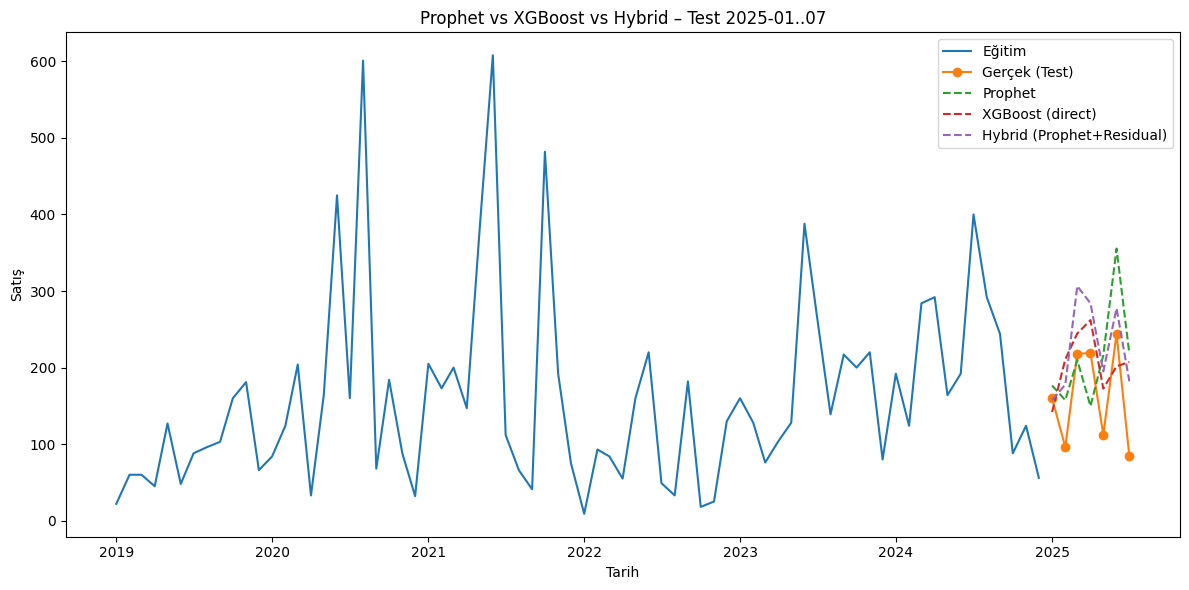

In [1]:
# ============================================
#  Hybrid Forecast: Prophet + XGBoost Residual
#  Train: 2019-01..2024-12 (MS)
#  Test : 2025-01..2025-07 (MS)
#  Özellikler: month, year, is_summer, is_winter, lag1, lag12
# ============================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ---------- 1) Veri ----------
data = {
"2019-01":22,"2019-02":60,"2019-03":60,"2019-04":45,"2019-05":127,
"2019-06":48,"2019-07":88,"2019-08":96,"2019-09":103,"2019-10":160,
"2019-11":181,"2019-12":66,"2020-01":84,"2020-02":124,"2020-03":204,
"2020-04":33,"2020-05":164,"2020-06":425,"2020-07":160,"2020-08":601,
"2020-09":68,"2020-10":184,"2020-11":88,"2020-12":32,"2021-01":205,
"2021-02":173,"2021-03":200,"2021-04":147,"2021-05":380,"2021-06":608,
"2021-07":112,"2021-08":66,"2021-09":41,"2021-10":482,"2021-11":192,
"2021-12":75,"2022-01":9,"2022-02":93,"2022-03":84,"2022-04":55,
"2022-05":160,"2022-06":220,"2022-07":49,"2022-08":33,"2022-09":182,
"2022-10":18,"2022-11":25,"2022-12":130,"2023-01":160,"2023-02":128,
"2023-03":76,"2023-04":104,"2023-05":128,"2023-06":388,"2023-07":264,
"2023-08":139,"2023-09":217,"2023-10":200,"2023-11":220,"2023-12":80,
"2024-01":192,"2024-02":124,"2024-03":284,"2024-04":292,"2024-05":164,
"2024-06":192,"2024-07":400,"2024-08":292,"2024-09":244,"2024-10":88,
"2024-11":124,"2024-12":56,"2025-01":160,"2025-02":96,"2025-03":218,
"2025-04":219,"2025-05":112,"2025-06":244,"2025-07":84
}

# Aylık seri (MS = Month Start) uyumlu index
s = pd.Series(data)
s.index = pd.to_datetime(s.index)                         # ayın 1'i
idx_all = pd.date_range("2019-01-01", "2025-07-01", freq="MS")
s = s.reindex(idx_all).astype(float)

df_all = pd.DataFrame({"ds": s.index, "y": s.values})
train_end = pd.Timestamp("2024-12-01")
test_start, test_end = pd.Timestamp("2025-01-01"), pd.Timestamp("2025-07-01")

train_df = df_all[df_all["ds"] <= train_end].copy()
test_df  = df_all[(df_all["ds"] >= test_start) & (df_all["ds"] <= test_end)].copy()
steps = len(test_df)
y_true = test_df["y"].to_numpy()

# ---------- 2) Prophet temel model ----------
m = Prophet(yearly_seasonality=True, weekly_seasonality=False)  # isterseniz seasonality_mode="multiplicative"
m.fit(train_df.rename(columns={"ds":"ds","y":"y"}))

future = m.make_future_dataframe(periods=steps, freq="MS")  # MS önemli!
fcst = m.predict(future)[["ds","yhat"]]

# Train ve Test için Prophet tahminlerini hizala
df_all = df_all.merge(fcst, on="ds", how="left")
prophet_train_pred = df_all.loc[df_all["ds"] <= train_end, "yhat"].to_numpy()
prophet_test_pred  = df_all.loc[(df_all["ds"] >= test_start) & (df_all["ds"] <= test_end), "yhat"].to_numpy()

# ---------- 3) Özellikler + laglar ----------
def add_features(df):
    df = df.copy()
    df["month"] = df["ds"].dt.month
    df["year"] = df["ds"].dt.year
    df["is_summer"] = df["ds"].dt.month.isin([6,7,8]).astype(int)
    df["is_winter"] = df["ds"].dt.month.isin([12,1,2]).astype(int)
    # Lag'ler (ham satıştan): 1 ve 12 ay
    df["lag1"]  = df["y"].shift(1)
    df["lag12"] = df["y"].shift(12)
    return df

feat_all = add_features(df_all[["ds","y","yhat"]])

# Residual = y - Prophet_yhat (train için)
feat_all["residual"] = feat_all["y"] - feat_all["yhat"]

# ---------- 4) XGBoost – residual modeli (kampanyasız) ----------
# Train satırları: residual mevcut ve lag'ler NaN değil
mask_train_res = (feat_all["ds"] <= train_end) & feat_all[["lag1","lag12"]].notna().all(axis=1)
train_res = feat_all.loc[mask_train_res].copy()

X_cols = ["month","year","is_summer","is_winter","lag1","lag12"]
X_res_train = train_res[X_cols]
y_res_train = train_res["residual"]

xgb_res = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42
)
xgb_res.fit(X_res_train, y_res_train)

# Test satırları: lag'ler mevcut olan 2025-01..07
mask_test = (feat_all["ds"] >= test_start) & (feat_all["ds"] <= test_end)
test_res = feat_all.loc[mask_test].copy()

# Eğer ilk test ayı için lag1 NaN olsaydı (bizde değil), doldurma gerekirdi.
X_res_test = test_res[X_cols]
resid_pred_test = xgb_res.predict(X_res_test)

# Hybrid = Prophet_test + Residual_pred_test
hybrid_pred = prophet_test_pred + resid_pred_test

# (Opsiyonel) XGBoost-direct (özellikten direkt y)
# Prophet ve Hybrid ile kıyas için:
mask_train_direct = (feat_all["ds"] <= train_end)
train_direct = feat_all.loc[mask_train_direct].copy()
X_train_direct = train_direct[X_cols]
y_train_direct = train_direct["y"]

xgb_direct = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    random_state=42
)
xgb_direct.fit(X_train_direct, y_train_direct)
xgb_direct_pred = xgb_direct.predict(X_res_test)  # aynı X_cols seti

# ---------- 5) Metrikler ----------
def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    return np.mean(np.abs((y_true - y_pred) / np.where(y_true==0, 1, y_true))) * 100

def show_metrics(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mp   = mape(y_true, y_pred)
    print(f"{name} -> MAE: {mae:.2f}, RMSE: {rmse:.2f}, MAPE: {mp:.2f}%")
    return mae, rmse, mp

print("\n=== Test (2025-01..07) Sonuçları ===")
_ = show_metrics("Prophet", y_true, prophet_test_pred)
_ = show_metrics("XGBoost (direct, kampanyasız)", y_true, xgb_direct_pred)
_ = show_metrics("Hybrid (Prophet + XGB-residual)", y_true, hybrid_pred)

# ---------- 6) Grafik ----------
plt.figure(figsize=(12,6))
plt.plot(train_df["ds"], train_df["y"], label="Eğitim")
plt.plot(test_df["ds"],  test_df["y"],  label="Gerçek (Test)", marker="o")
plt.plot(test_df["ds"],  prophet_test_pred, "--", label="Prophet")
plt.plot(test_df["ds"],  xgb_direct_pred, "--", label="XGBoost (direct)")
plt.plot(test_df["ds"],  hybrid_pred, "--", label="Hybrid (Prophet+Residual)")
plt.title("Prophet vs XGBoost vs Hybrid – Test 2025-01..07")
plt.xlabel("Tarih"); plt.ylabel("Satış"); plt.legend(); plt.tight_layout()
plt.show()
